In [33]:
import pandas as pd

In [34]:

ord = pd.read_csv("olist_orders_dataset.csv")
cus = pd.read_csv("olist_customers_dataset.csv")


In [35]:
ord.columns


Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [36]:
cus.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

In [37]:
leftmerge = ord.merge(cus ,on='customer_id' , how='left')
print(leftmerge)

                               order_id                       customer_id  \
0      e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1      53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2      47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3      949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4      ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
...                                 ...                               ...   
99436  9c5dedf39a927c1b2549525ed64a053c  39bd1228ee8140590ac3aca26f2dfe00   
99437  63943bddc261676b46f01ca7ac2f7bd8  1fca14ff2861355f6e5f14306ff977a7   
99438  83c1379a015df1e13d02aae0204711ab  1aa71eb042121263aafbe80c1b562c9c   
99439  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
99440  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

      order_status order_purchase_timestamp    order_approved_at  \
0      

In [38]:
len(ord)


99441

In [39]:
len(leftmerge)

99441

In [40]:
cus['customer_id'].duplicated().sum()

np.int64(0)

In [41]:
pay = pd.read_csv("olist_order_payments_dataset.csv")
itm = pd.read_csv("olist_order_items_dataset.csv")

In [42]:
pay.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')

In [43]:
itm.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [44]:
itm['order_id'].duplicated().sum()


np.int64(13984)

In [45]:
pay['order_id'].duplicated().sum()

np.int64(4446)

In [46]:
merge2 = leftmerge.merge(itm ,on='order_id', how='left')
print(merge2)

                                order_id                       customer_id  \
0       e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1       53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2       47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3       949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4       ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
...                                  ...                               ...   
113420  63943bddc261676b46f01ca7ac2f7bd8  1fca14ff2861355f6e5f14306ff977a7   
113421  83c1379a015df1e13d02aae0204711ab  1aa71eb042121263aafbe80c1b562c9c   
113422  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
113423  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
113424  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

       order_status order_purchase_timestamp    order_approved_

In [47]:
len(leftmerge)

99441

In [48]:
len(merge2)

113425

In [49]:
# Sélection des colonnes numériques directement disponibles dans merge2
cols_num = ["price", "freight_value"]

# Matrice de corrélation
corr_matrix = merge2[cols_num].corr()
print(corr_matrix)

                  price  freight_value
price          1.000000       0.414204
freight_value  0.414204       1.000000


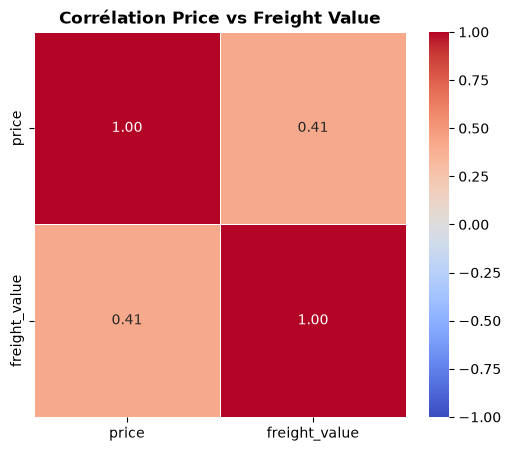

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
)
plt.title("Corrélation Price vs Freight Value", weight="bold")
plt.show()

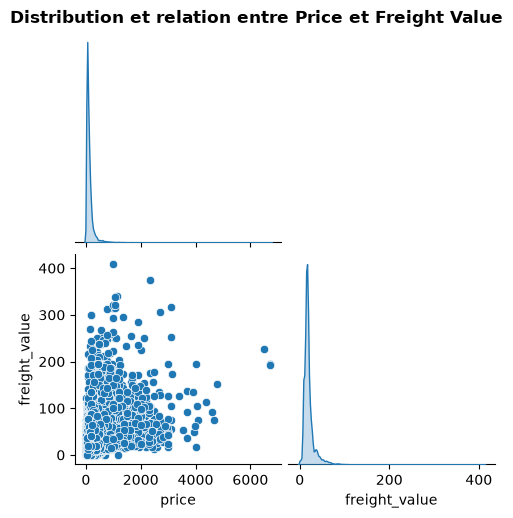

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualisation des distributions et des relations
sns.pairplot(
    merge2[['price', 'freight_value']].dropna(),
    diag_kind='kde', # Courbe de densité sur la diagonale
    corner=True # Supprime la partie supérieure redondante
)

plt.suptitle("Distribution et relation entre Price et Freight Value", y=1.02, weight='bold')
plt.show()